# Clustering Demo
Load DINOv2 features → PCA → KMeans → visualize → inspect representative clips per cluster.

In [1]:
# install dependencies if needed
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', 'hdbscan', '-q'])


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'scikit-learn', 'hdbscan', '-q'], returncode=0)

In [2]:
import sys
import os
import logging
sys.path.append('..')
os.chdir('..')  # run from project root so data/ paths resolve correctly

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path

from phase2.cluster import (
    load_and_prepare, cluster_kmeans, cluster_hdbscan,
    get_representatives, pca_2d, save_clusters
)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)

VIDEOS_DIR = Path('data/videos')

## 1. Load and prepare features

In [3]:
features_pca, features_raw, video_ids, start_secs, end_secs = load_and_prepare(pca_components=50)

print(f'Total segments : {len(features_pca)}')
print(f'Feature dim    : {features_pca.shape[1]} (after PCA)')
print(f'Videos         : {sorted(set(video_ids))}')

13:08:12 [INFO] phase2.cluster: Loaded 84 feature vectors  (dim=768)
13:08:12 [INFO] phase2.cluster: PCA: 768 → 50 dims  (95.8% variance retained)


Total segments : 84
Feature dim    : 50 (after PCA)
Videos         : ['Hwji93BVjnI', 'LITlLW9bYNs', 'LNEaa_cNf9M', 'TFzpC_e44Tg', 'abRPaXgJGQg', 'ebeNeQFUMa0', 'lRrkaLTVHrs', 'oSyEZAm8nb8', 'qnMxd3s6u-c', 'tmJtd9BLCuc']


## 2. Choose number of clusters
Set `K` to the number of behaviors in your ethogram. Try a few values and look at the elbow plot.

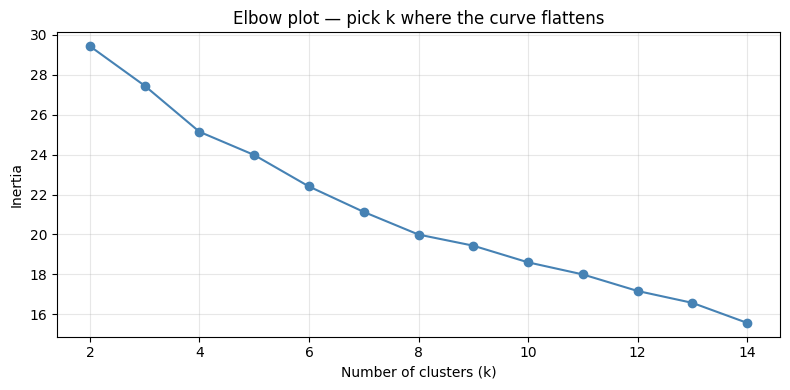

In [4]:
# elbow plot — inertia vs k
from sklearn.cluster import KMeans

ks = range(2, min(15, len(features_pca)))
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(ks), inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow plot — pick k where the curve flattens')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
K = 6  # set this to match your ethogram size

labels, km_model = cluster_kmeans(features_pca, k=K)
print(f'\nCluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}')

13:08:13 [INFO] phase2.cluster: Running KMeans with k=6 ...
13:08:13 [INFO] phase2.cluster:   Cluster  0 : 7 segments
13:08:13 [INFO] phase2.cluster:   Cluster  1 : 15 segments
13:08:13 [INFO] phase2.cluster:   Cluster  2 : 25 segments
13:08:13 [INFO] phase2.cluster:   Cluster  3 : 4 segments
13:08:13 [INFO] phase2.cluster:   Cluster  4 : 24 segments
13:08:13 [INFO] phase2.cluster:   Cluster  5 : 9 segments
13:08:13 [INFO] phase2.cluster: Inertia: 22.40



Cluster sizes: {np.int32(0): np.int64(7), np.int32(1): np.int64(15), np.int32(2): np.int64(25), np.int32(3): np.int64(4), np.int32(4): np.int64(24), np.int32(5): np.int64(9)}


## 3. Visualize clusters in 2D (PCA)

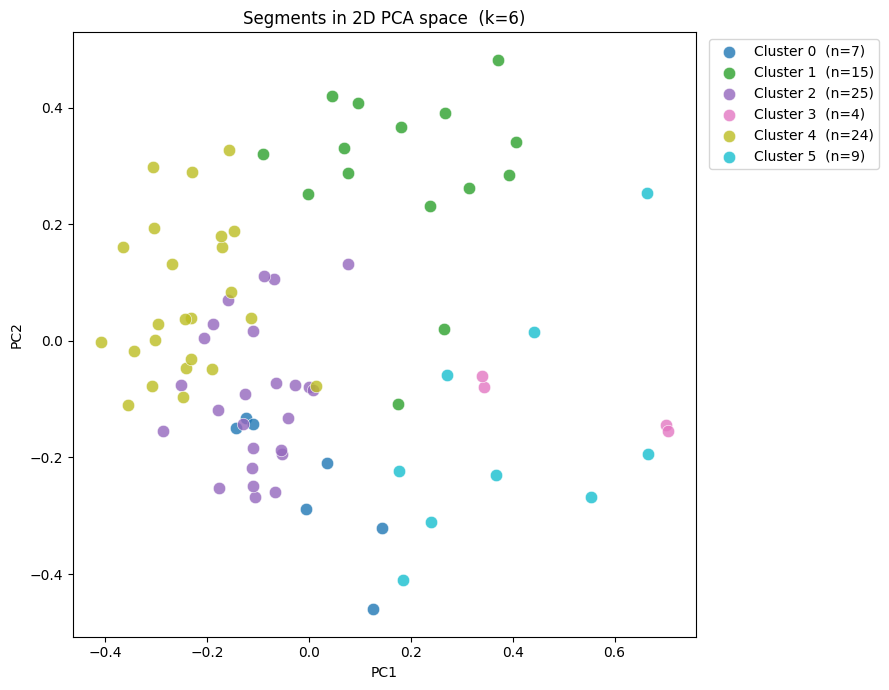

In [6]:
coords_2d = pca_2d(features_pca)
colors = plt.cm.tab10(np.linspace(0, 1, K))

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(K):
    mask = labels == i
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               color=colors[i], label=f'Cluster {i}  (n={mask.sum()})',
               s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

ax.set_title(f'Segments in 2D PCA space  (k={K})', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 4. Representative frames per cluster
These are the 5 segments closest to each cluster centroid. Watch these and assign an ethogram label.

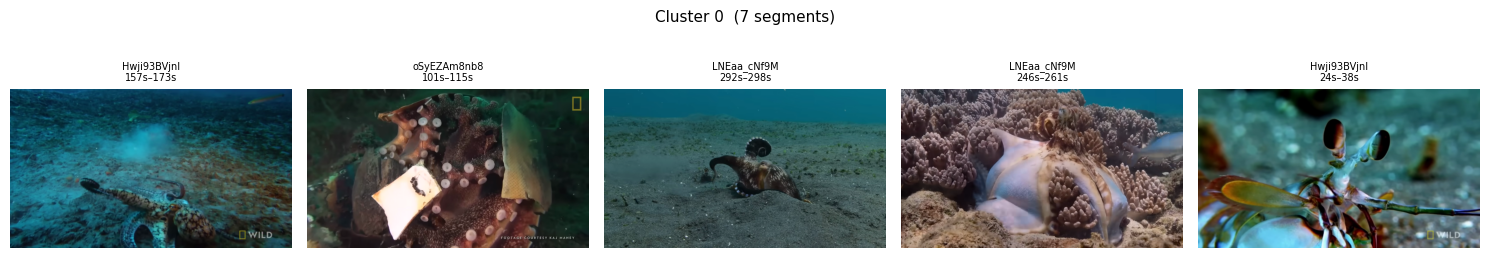

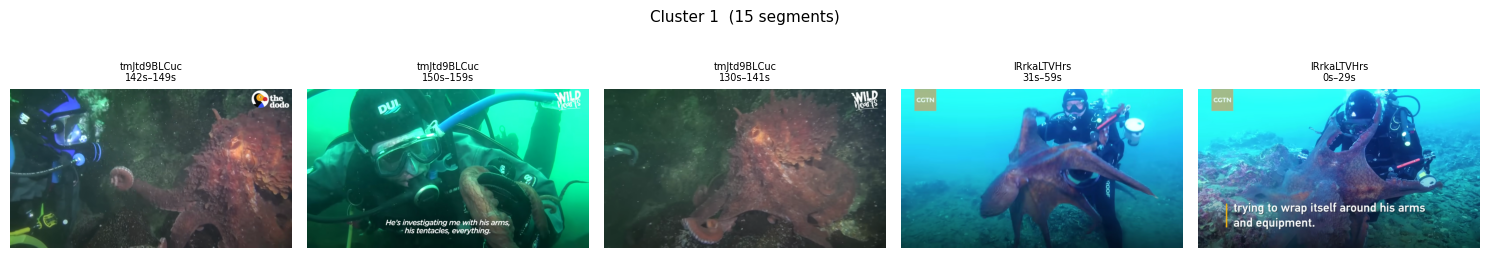

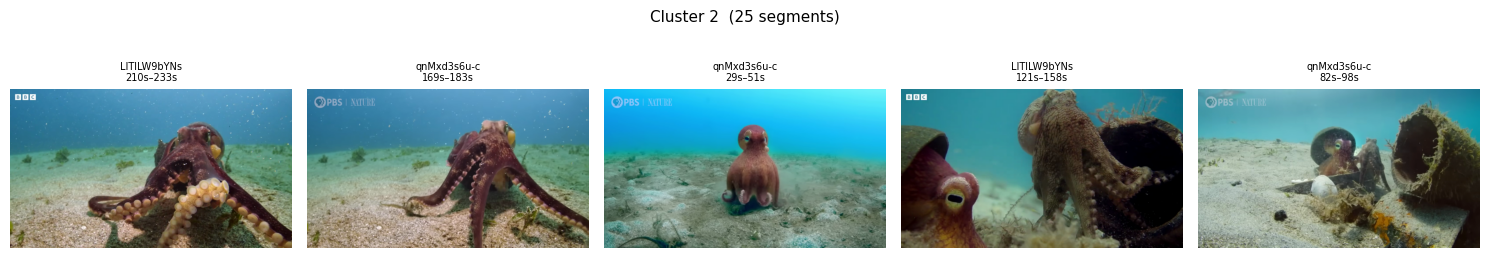

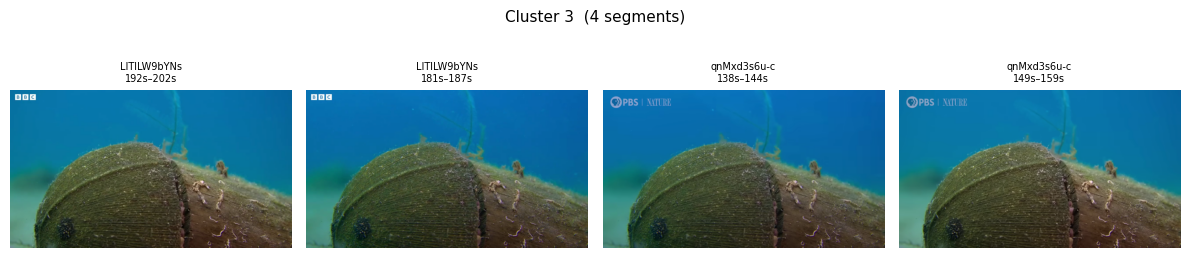

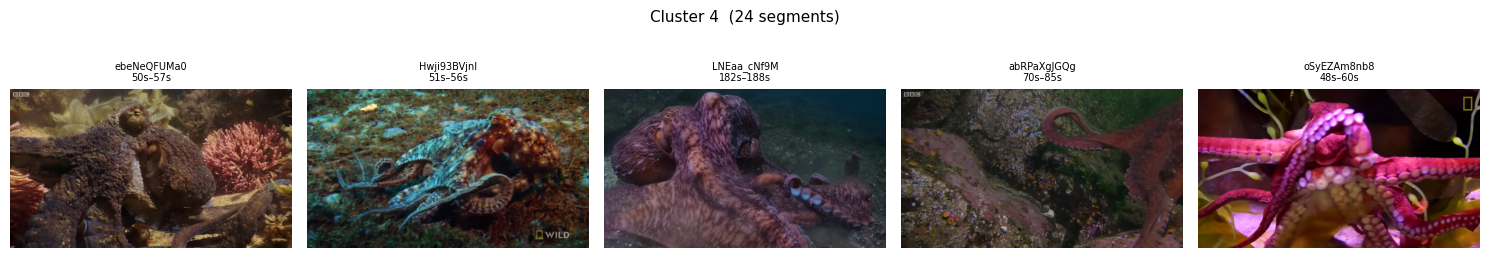

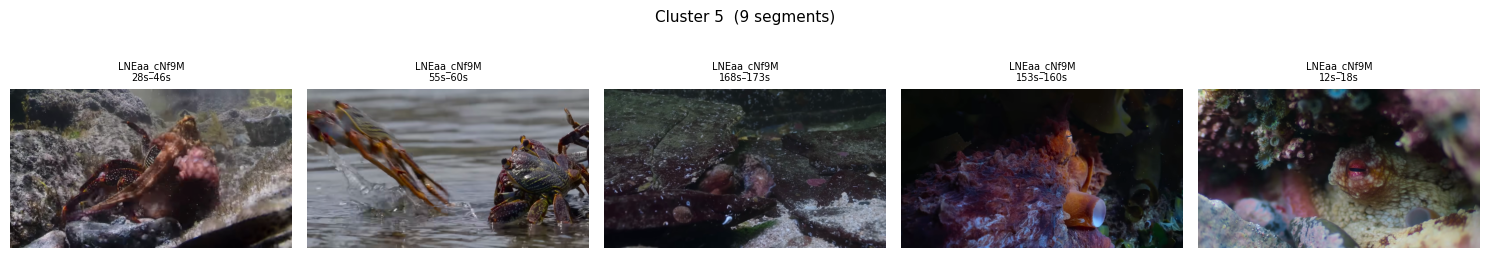

In [7]:
def grab_frame(video_id, timestamp_sec):
    path = VIDEOS_DIR / f'{video_id}.mp4'
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(timestamp_sec * fps))
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else None


reps = get_representatives(features_pca, labels, n=5)

for cluster_id, idxs in reps.items():
    fig, axes = plt.subplots(1, len(idxs), figsize=(3 * len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]
    fig.suptitle(f'Cluster {cluster_id}  ({(labels == cluster_id).sum()} segments)', fontsize=11)

    for ax, idx in zip(axes, idxs):
        mid = (start_secs[idx] + end_secs[idx]) / 2
        frame = grab_frame(video_ids[idx], mid)
        if frame is not None:
            ax.imshow(frame)
        ax.set_title(f'{video_ids[idx]}\n{start_secs[idx]:.0f}s–{end_secs[idx]:.0f}s', fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 5. Assign ethogram labels
After reviewing the frames above, fill in the label for each cluster.

In [8]:
# Fill these in after reviewing cluster frames above
CLUSTER_LABELS = {
    0: 'unlabelled',
    1: 'unlabelled',
    2: 'unlabelled',
    3: 'unlabelled',
    4: 'unlabelled',
    5: 'unlabelled',
}

# print summary
print(f'{'Cluster':>10}  {'Label':>20}  {'Segments':>10}')
print('-' * 45)
for cid, lbl in CLUSTER_LABELS.items():
    n = (labels == cid).sum()
    print(f'{cid:>10}  {lbl:>20}  {n:>10}')

   Cluster                 Label    Segments
---------------------------------------------
         0            unlabelled           7
         1            unlabelled          15
         2            unlabelled          25
         3            unlabelled           4
         4            unlabelled          24
         5            unlabelled           9


## 6. Save cluster assignments

In [9]:
save_clusters(labels, video_ids, start_secs, end_secs, name=f'kmeans_k{K}')

# also save the human labels
import json
from pathlib import Path
labels_path = Path('../data/phase2/clusters') / f'kmeans_k{K}_labels.json'
labels_path.write_text(json.dumps(CLUSTER_LABELS, indent=2))
print(f'Saved cluster assignments and labels')

13:08:18 [INFO] phase2.cluster: Saved cluster assignments → data/phase2/clusters/kmeans_k6.npz


FileNotFoundError: [Errno 2] No such file or directory: '../data/phase2/clusters/kmeans_k6_labels.json'